#  IBM HR Analytics: Predicting and Understanding Employee Attrition

**Author**: Hacer Özkan

**Date**: January 2026

**Objective**: To identify the key factors that cause employees to leave the company using statistical analysis and data visualization in R.

Attrition,n,percentage
<fct>,<int>,<dbl>
No,1233,83.87755
Yes,237,16.12245


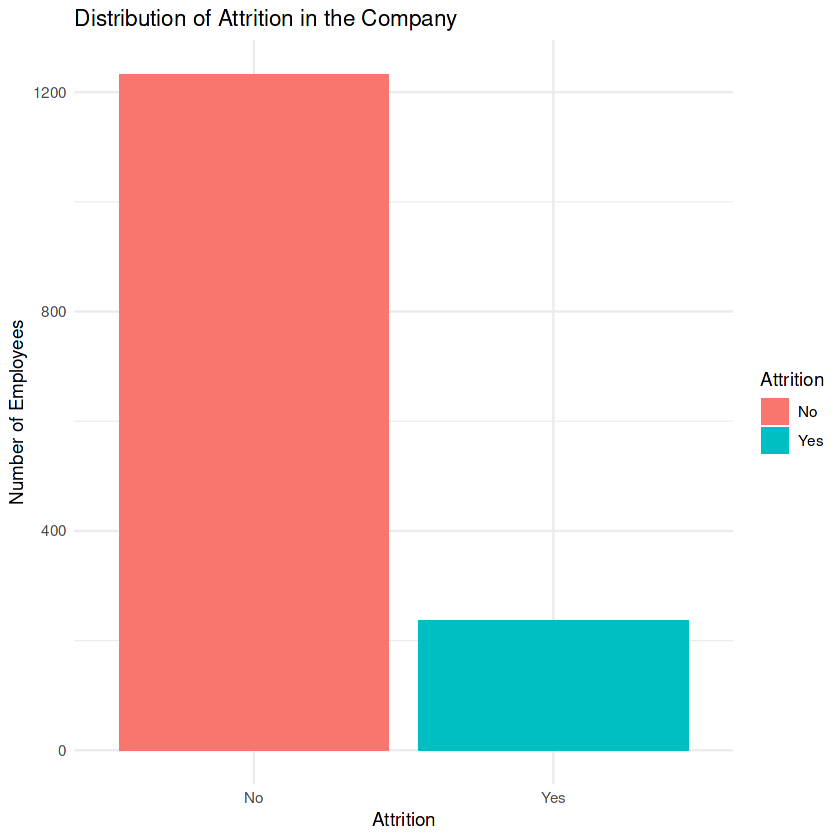

In [6]:
library(tidyverse)
library(corrplot)
library(scales)
library(readr)

# Load data (Adjust path for Kaggle: /kaggle/input/...)
hr_data_raw <- read.csv(
  "/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

# Data Cleaning
clean_df <- hr_data_raw %>% 
  select(-EmployeeCount, -Over18, -StandardHours, -EmployeeNumber) %>%
  mutate(
    Attrition = as.factor(Attrition),
    Department = as.factor(Department),
    EducationField = as.factor(EducationField),
    Gender = as.factor(Gender),
    JobRole = as.factor(JobRole),
    MaritalStatus = as.factor(MaritalStatus),
    OverTime = as.factor(OverTime),
    BusinessTravel = as.factor(BusinessTravel),
    EnvironmentSatisfaction = as.factor(EnvironmentSatisfaction),
    JobSatisfaction = as.factor(JobSatisfaction),
    WorkLifeBalance = as.factor(WorkLifeBalance)
  )

# Overall Attrition Rate
clean_df %>% count(Attrition) %>% mutate(percentage = (n/sum(n))*100)

ggplot(clean_df, aes(x=Attrition, fill=Attrition)) + 
  geom_bar() + 
  theme_minimal() + 
  labs(title="Distribution of Attrition in the Company", y="Number of Employees")

Does lower income lead to higher attrition?


We use a Boxplot for visualization and a T-test for statistical significance.



	Welch Two Sample t-test

data:  MonthlyIncome by Attrition
t = 7.4826, df = 412.74, p-value = 4.434e-13
alternative hypothesis: true difference in means between group No and group Yes is not equal to 0
95 percent confidence interval:
 1508.244 2583.050
sample estimates:
 mean in group No mean in group Yes 
         6832.740          4787.093 


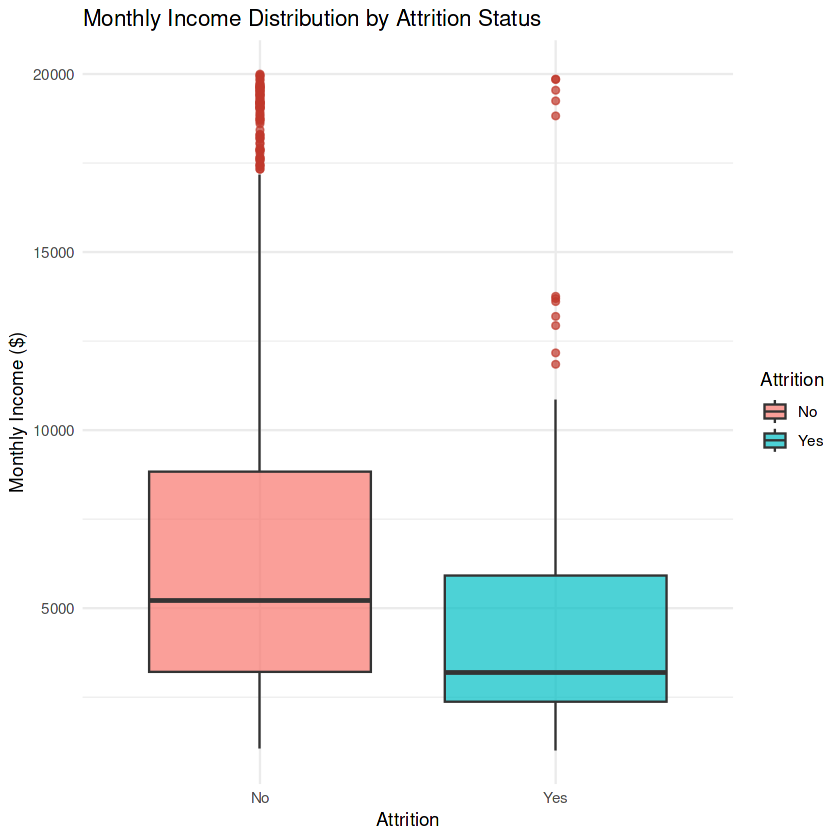

In [7]:
ggplot(clean_df, aes(x = Attrition, y = MonthlyIncome, fill = Attrition)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "#c0392b") +
  theme_minimal() +
  labs(title = "Monthly Income Distribution by Attrition Status", x = "Attrition", y = "Monthly Income ($)")

# T-Test
t.test(MonthlyIncome ~ Attrition, data = clean_df)

**Statistical Interpretation: Monthly Income vs Attrition**

**Finding**: A Welch Two Sample t-test was conducted to compare the monthly income of employees who stayed (No) and those who left (Yes).

**$p$-value**: $4.434 \times 10^{-13}$ (Significantly lower than 0.05).

**Confidence Interval** : [1508.24, 2583.05] (Zero is not included, confirming a real difference).

**Means** : Employees who stayed earn an average of USD 6,832 , while those who left earn an average of USD 4,787.

**Conclusion**: We reject the Null Hypothesis ($H_0$). There is a statistically significant difference in income. On average, employees who resigned were earning USD 2,045 less per month than those who remained.

**Business Insight**: Financial compensation is a primary driver of attrition. The company should benchmark the salaries of high-turnover roles against industry standards to improve retention.

The Impact of Overtime on Attrition

Checking if employees who work overtime are more likely to leave.


	Pearson's Chi-squared test with Yates' continuity correction

data:  table(clean_df$OverTime, clean_df$Attrition)
X-squared = 87.564, df = 1, p-value < 2.2e-16


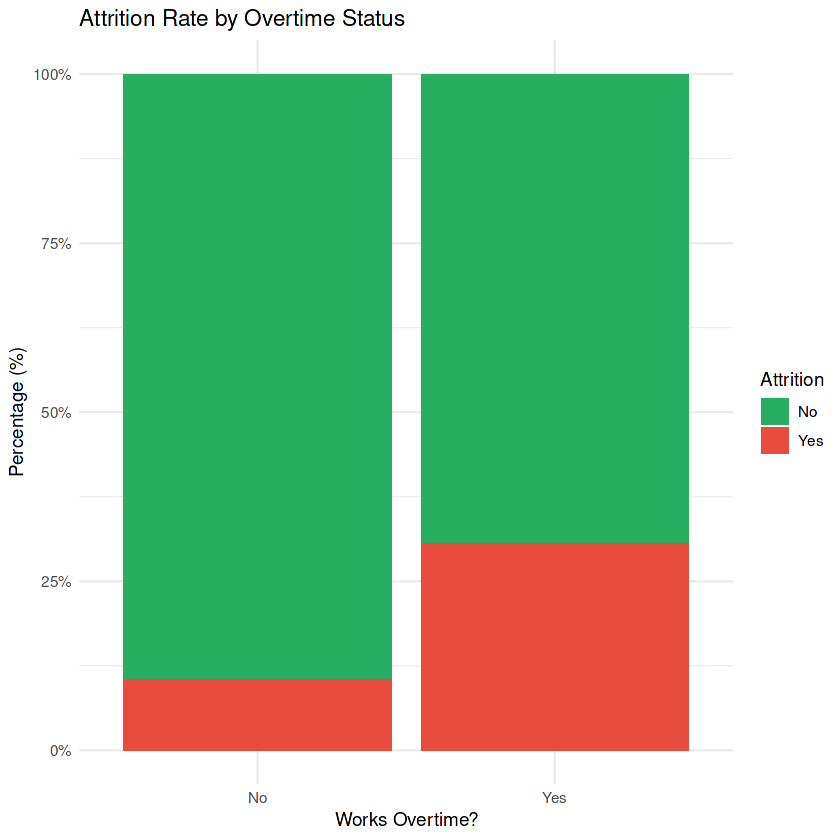

In [8]:
ggplot(clean_df, aes(x = OverTime, fill = Attrition)) +
  geom_bar(position = "fill") + 
  scale_y_continuous(labels = percent) +
  scale_fill_manual(values = c("No" = "#27ae60", "Yes" = "#e74c3c")) +
  theme_minimal() +
  labs(title = "Attrition Rate by Overtime Status", x = "Works Overtime?", y = "Percentage (%)")

# Chi-Square Test
chisq.test(table(clean_df$OverTime, clean_df$Attrition))

**Statistical Interpretation: Overtime vs Attrition**# 

**Finding**: A Pearson's Chi-squared test was performed to examine the relationship between working overtime and employee attrition.

**$\chi^2$ (Chi-squared)**: $87.564$$p$-value: $< 2.2 \times 10^{-16}$ (Highly significant).

**Conclusion:** We reject the Null Hypothesis ($H_0$). There is a very strong and statistically significant association between overtime and attrition.

**Business Insight**: Working overtime is one of the most critical risk factors for turnover in this organization. Employees who are required to work extra hours are significantly more likely to leave. This suggests that "Burnout" might be a major issue. Management should investigate workload distribution and consider implementing more flexible working hours or hiring additional staff to reduce the pressure on current employees.

Comparing Income and Satisfaction across Departments

              Df    Sum Sq  Mean Sq F value Pr(>F)  
Department     2 1.415e+08 70754962   3.202  0.041 *
Residuals   1467 3.242e+10 22098613                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = MonthlyIncome ~ Department, data = clean_df)

$Department
                                            diff         lwr      upr     p adj
Research & Development-Human Resources -373.2551 -1807.57002 1061.060 0.8143913
Sales-Human Resources                   304.6647 -1179.72420 1789.054 0.8800639
Sales-Research & Development            677.9198    46.02548 1309.814 0.0320059


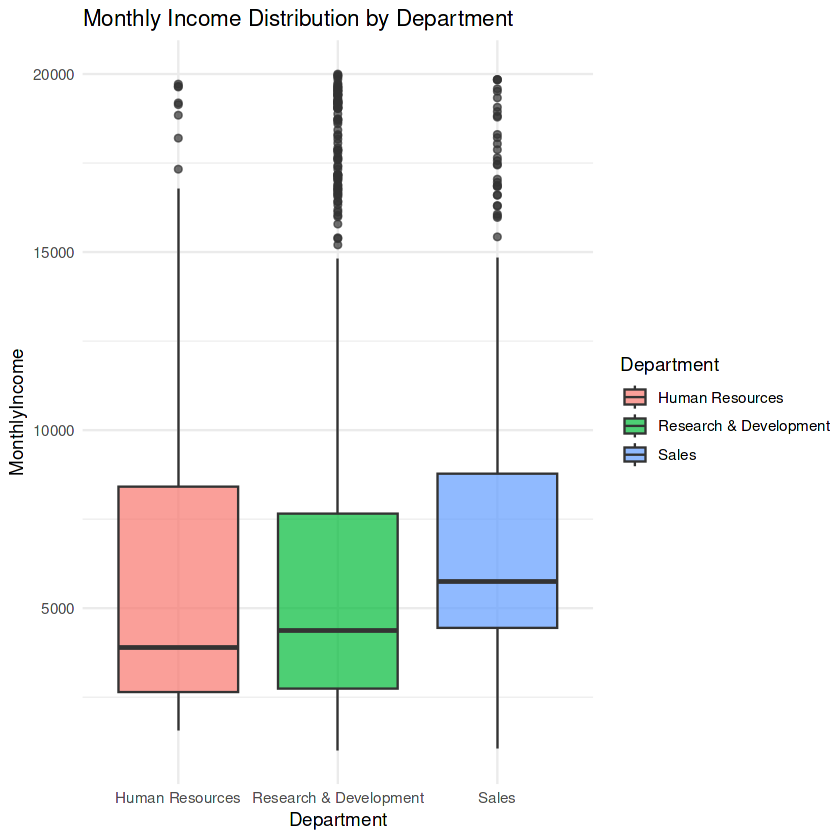

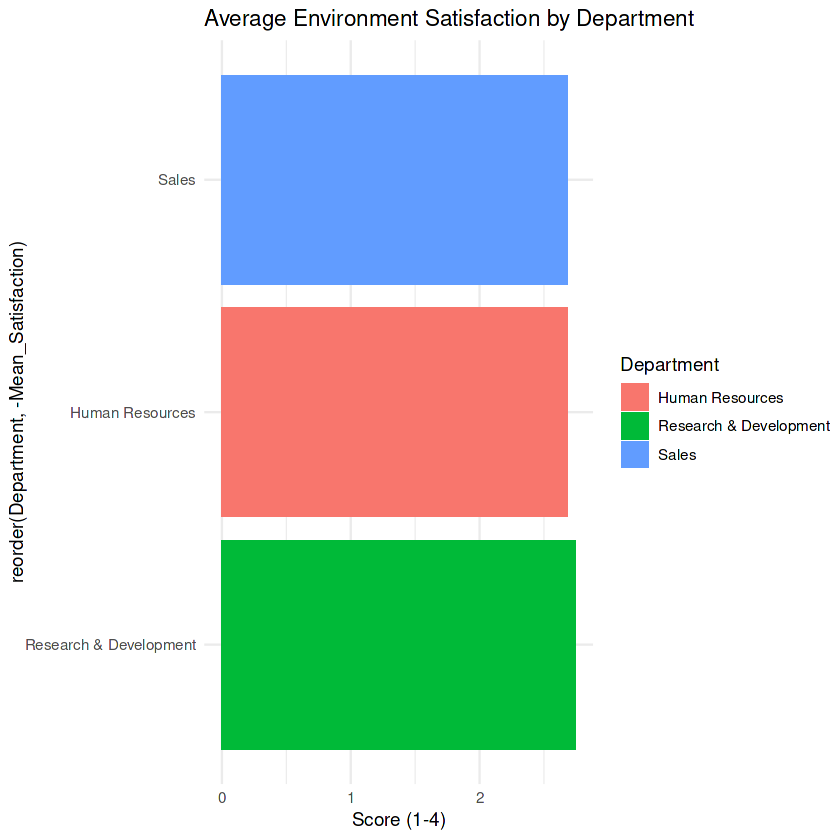

In [9]:
# ANOVA for Monthly Income
ggplot(clean_df, aes(x = Department, y = MonthlyIncome, fill = Department)) +
  geom_boxplot(alpha = 0.7) + theme_minimal() +
  labs(title = "Monthly Income Distribution by Department")

anova_income <- aov(MonthlyIncome ~ Department, data = clean_df)
summary(anova_income)
TukeyHSD(anova_income)

# Average Environment Satisfaction
dept_satisfaction <- clean_df %>%
  group_by(Department) %>%
  summarise(Mean_Satisfaction = mean(as.numeric(EnvironmentSatisfaction)))

ggplot(dept_satisfaction, aes(x = reorder(Department, -Mean_Satisfaction), y = Mean_Satisfaction, fill = Department)) +
  geom_col() + coord_flip() + theme_minimal() +
  labs(title = "Average Environment Satisfaction by Department", y = "Score (1-4)")

**Statistical Interpretation: Monthly Income by Department (ANOVA)**# 

**Finding:** A One-Way ANOVA was conducted to determine if monthly income differs across the three departments (HR, R&D, and Sales).

**$p$-value:** $0.041$ (Statistically significant at the 5% level).

**Tukey HSD Post-Hoc Analysis:** 

* **Sales vs. Research & Development**: Significant difference found ($p = 0.032$). On average, Sales employees earn $677.92 more than R&D employees.

* **Sales vs. Human Resources:** No significant difference ($p = 0.880$).R&D vs. Human Resources: No significant difference ($p = 0.814$).

**Conclusion:** We reject the Null Hypothesis ($H_0$). There is a statistically significant difference in mean income between at least two departments.

**Business Insight:** The Sales department has the highest average income, which is statistically higher than R&D. This could be due to commission-based structures or different market demands for these roles. However, the company should ensure that the income gap doesn't lead to demotivation in the R&D department, which is essential for long-term product development.



"People leave managers, not companies"
We analyze if the time spent with the current manager affects attrition.


	Welch Two Sample t-test

data:  YearsWithCurrManager by Attrition
t = 6.6334, df = 365.1, p-value = 1.185e-10
alternative hypothesis: true difference in means between group No and group Yes is not equal to 0
95 percent confidence interval:
 1.065929 1.964223
sample estimates:
 mean in group No mean in group Yes 
         4.367397          2.852321 


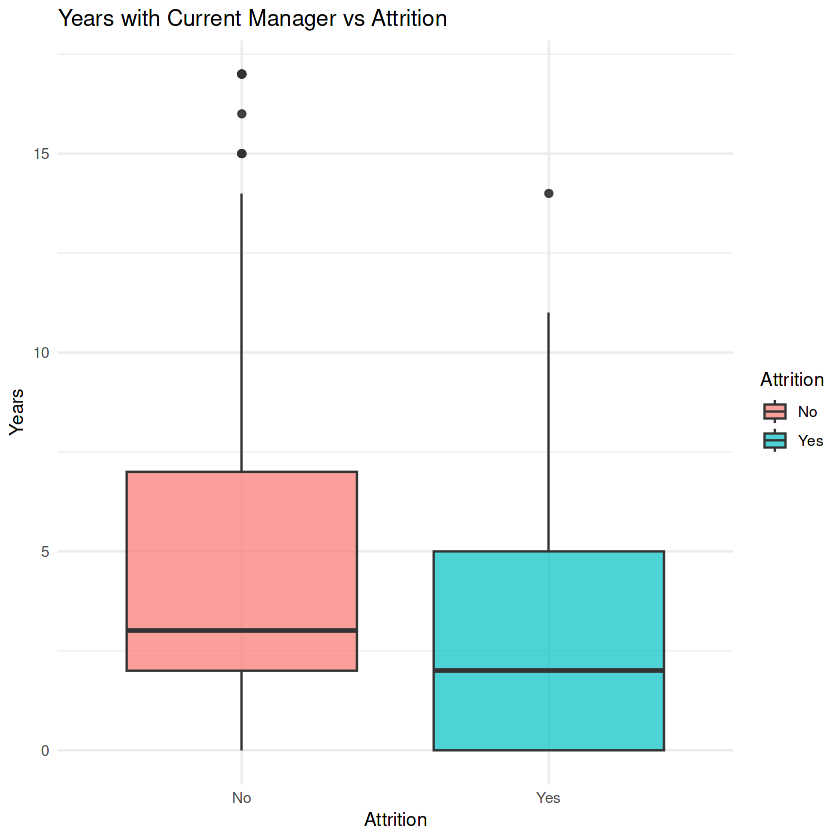

In [11]:
ggplot(clean_df, aes(x = Attrition, y = YearsWithCurrManager, fill = Attrition)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal() +
  labs(title = "Years with Current Manager vs Attrition", y = "Years")

# T-Test for Manager Relationship
t.test(YearsWithCurrManager ~ Attrition, data = clean_df)

**Statistical Interpretation: Years with Current Manager vs Attrition**

**Finding:** A Welch Two Sample t-test was conducted to investigate the impact of the manager-employee relationship duration on attrition.

* **$p$-value:** $1.185 \times 10^{-10}$ (Extremely significant).

* **Means:** Employees who stayed have been with their current manager for an average of 4.37 years, while those who left had only 2.85 years of tenure with their manager.

* **Difference:** On average, employees who resigned had 1.5 years less time with their manager compared to those who stayed.

**Conclusion:** We reject the Null Hypothesis ($H_0$). There is a strong statistical link between shorter manager relationships and the likelihood of attrition.

**Business Insight:** The first two years of a manager-employee relationship are high-risk periods. This suggests that either the "onboarding" phase with new managers is failing, or there is a lack of trust/loyalty built in the early years.


Commute Impact: Distance from Home

Analyzing if a longer commute increases the likelihood of resignation.


	Welch Two Sample t-test

data:  DistanceFromHome by Attrition
t = -2.8882, df = 322.72, p-value = 0.004137
alternative hypothesis: true difference in means between group No and group Yes is not equal to 0
95 percent confidence interval:
 -2.8870025 -0.5475146
sample estimates:
 mean in group No mean in group Yes 
         8.915653         10.632911 


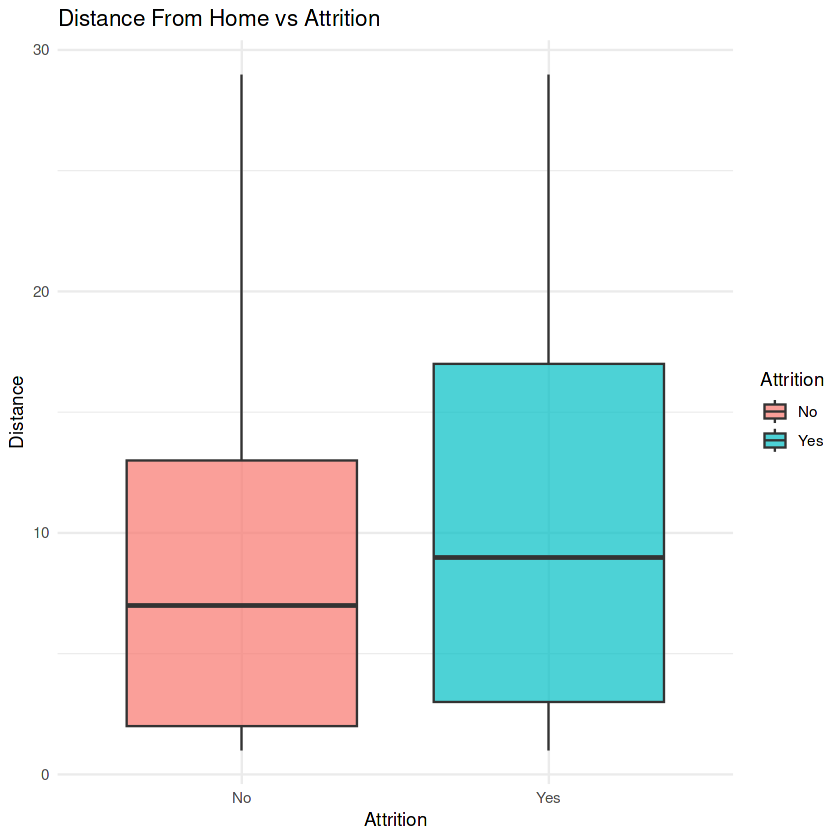

In [10]:
ggplot(clean_df, aes(x = Attrition, y = DistanceFromHome, fill = Attrition)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal() +
  labs(title = "Distance From Home vs Attrition", y = "Distance")

# T-Test for Distance
t.test(DistanceFromHome ~ Attrition, data = clean_df)

**Statistical Interpretation: Distance From Home vs Attrition**

**Finding:** A Welch Two Sample t-test was conducted to see if commute distance affects attrition.

**$p$-value:** $0.0041$ (Statistically significant).

**Means:** Employees who left lived further away (10.63 units) compared to those who stayed (8.91 units).

**Conclusion:** We reject the Null Hypothesis ($H_0$). Longer commutes are significantly associated with higher attrition.

**Business Insight:** Physical distance is a clear barrier to retention. The company should consider flexible working hours or remote work options for employees with long commutes to reduce burnout and resignation risk.

The Big Picture and Prediction
Visualizing all numerical relationships and building a Logistic Regression model.


Call:
glm(formula = Attrition ~ MonthlyIncome + OverTime + Age + DistanceFromHome + 
    JobSatisfaction + YearsWithCurrManager, family = "binomial", 
    data = clean_df)

Coefficients:
                       Estimate Std. Error z value Pr(>|z|)    
(Intercept)           8.877e-02  3.614e-01   0.246 0.805974    
MonthlyIncome        -7.618e-05  2.536e-05  -3.004 0.002669 ** 
OverTimeYes           1.453e+00  1.561e-01   9.310  < 2e-16 ***
Age                  -3.556e-02  1.002e-02  -3.550 0.000385 ***
DistanceFromHome      2.870e-02  9.171e-03   3.130 0.001750 ** 
JobSatisfaction2     -4.473e-01  2.316e-01  -1.932 0.053413 .  
JobSatisfaction3     -4.888e-01  2.051e-01  -2.383 0.017157 *  
JobSatisfaction4     -1.026e+00  2.192e-01  -4.679 2.88e-06 ***
YearsWithCurrManager -1.011e-01  2.677e-02  -3.778 0.000158 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1298.6  on 1469  degrees of

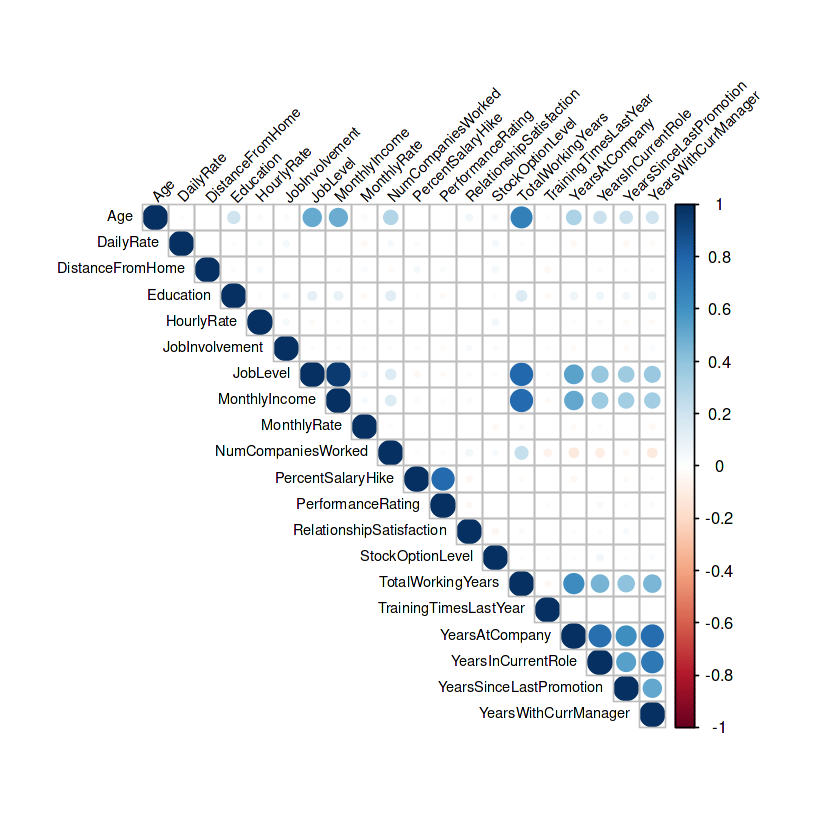

In [12]:
# Correlation Matrix
numeric_cols <- clean_df %>% select_if(is.numeric)
corr_matrix <- cor(numeric_cols)
corrplot(corr_matrix, method = "circle", type = "upper", tl.col = "black", tl.srt = 45, tl.cex = 0.7)

# Logistic Regression
model <- glm(Attrition ~ MonthlyIncome + OverTime + Age + DistanceFromHome + JobSatisfaction + YearsWithCurrManager, 
             data = clean_df, 
             family = "binomial")

summary(model)

**Final Conclusion & Strategic Insights**# 

This project analyzed 1,470 employee records to identify the primary drivers of attrition. By combining exploratory data analysis, statistical testing, and predictive modeling (Logistic Regression), the following key conclusions have been reached:

**1. The Dominant Drivers of Turnover**

* **Workload & Overtime:**   Our analysis and model confirm that Overtime is the strongest predictor of attrition. Employees working extra hours are at a significantly higher risk of leaving, suggesting a "Burnout" culture that needs management intervention.

* **Financial Compensation:**  Statistical tests show a significant pay gap (approx. $2,000) between those who stay and those who leave. Lower-income roles are the most vulnerable to turnover.

**2. The Human and Environmental Factor**

* **Leadership & Management:** Shorter relationships with managers correlate with higher attrition ($p < 0.001$). This supports the theory that leadership is key to retention; employees are more likely to stay as trust and loyalty are built over time with their supervisors.

* **Job Satisfaction:**  Satisfaction levels vary across departments, directly affecting retention. Higher satisfaction levels (Level 3 and 4) act as a strong protective barrier against resignation.

**3. Physical and Demographic Risks**

* **Commute Distance:** Longer distances from home significantly increase the likelihood of attrition. This highlights the importance of work-life balance and the potential benefit of flexible work arrangements.

* **Age and Tenure:** Younger employees and those with less tenure in their current roles are more mobile, requiring targeted engagement programs.

**Business Recommendations**

**1.Workload Management:** Reduce mandatory overtime and monitor employee burnout, especially in high-pressure departments like Sales.

**2.Compensation Benchmarking:** Review salary structures for entry-level and mid-level positions to ensure market competitiveness.

**3.Leadership Training:** Invest in manager-employee relationship building and "Stay Interviews" within the first two years of a manager-employee pairing.

**4. Flexibility:** Implement remote work or flexible scheduling for employees with long commutes to mitigate the "Distance Factor."